# Flood · Solar — M3 damage: capex-weighted depth-damage over all three sub-perils

**Peril:** Flood · **Asset:** Solar · **Layer:** M3 (damage) · sub-perils `riverine` + `pluvial` + `coastal`
(the solar M3 prices all three; per JD-FL-17, LA3 West Baton Rouge is the all-three solar site)

**Magnitude metric:** flood **depth (ft above ground)** — the source-agnostic intensity for all three sub-perils;
riverine/pluvial conditional depth by return period, coastal surge conditional depth per storm.

**Data source:** the canonical **`infrasure-damage-curves`** library — **RIVERINE_FLOOD × solar** (`FLOOD_x_SOLAR.md`,
the infrasure-damage-curves library, priority 4); NREL solar BoS capex weights; M2 coupled depths.

**What this notebook does:** maps the M2 coupled flood depth → a **capex-weighted subsystem damage ratio**, then
`conditional_loss = exposure × Asset_DR(conditional_depth) × TIV`. The house recipe (same as hail / wildfire / wind):
per-subsystem logistic `DR(x)=L/(1+exp(-k(x-x0)))`, anchored `DR(0)=0`, blended by capex weights. **One
source-agnostic curve** applies to all three sub-perils — riverine/pluvial by return period and coastal surge per
storm. The flood-specific physics — the **height inversion** — is baked into each `x0`: ground-level **inverters
drown at ~0.75 ft**, while elevated **panels (x0 2.5 ft) survive shallow water** and underground **cables are
resilient** (L 0.55), so `x0` itself encodes component elevation and no separate mount-height step is needed.

> Plan: [`m3_damage.md`](../../../../docs/plans/flood/m3_damage.md) · Curves vendored to
> `data/flood/damage_curves/` for reproducibility. **Confidence: medium**; duration unmodeled (Gen-1).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"
FT_M = 0.3048

m2 = pd.DataFrame(json.loads((OUT / "flood_solar_m2_coupling_manifest.json").read_text())["rows"])
print("M2 coupling contract (input — all sub-perils):")
print(m2[["sub_peril", "name", "rp_years", "exposure_fraction", "conditional_depth_m"]].to_string(index=False))

M2 coupling contract (input — all sub-perils):
sub_peril                                name  rp_years  exposure_fraction  conditional_depth_m
 riverine                Hayhurst Texas Solar       100              0.087                0.159
 riverine                Hayhurst Texas Solar       500              0.150                0.183
 riverine               Elizabeth Solar Plant       100              0.177                0.433
 riverine               Elizabeth Solar Plant       500              0.218                0.532
 riverine LA3 West Baton Rouge Solar Facility       100              0.509                0.355
 riverine LA3 West Baton Rouge Solar Facility       500              0.953                0.335
 riverine               Elizabeth Solar Plant        10              0.102                0.307
 riverine               Elizabeth Solar Plant        25              0.132                0.359
 riverine               Elizabeth Solar Plant        50              0.154               

## 1 · The curve library — RIVERINE_FLOOD × solar (vendored)

Five subsystems carry a flood curve; MOUNTING + SCADA have none → **flood-immune** (0 DR; steel piles resilient,
SCADA minor/elevated). PV_ARRAY uses the **single-axis horizontal-stow** variant (typical utility tracker); the
**flood-stow** variant (x0 7 ft) is a *mitigation lever*, noted for M-resiliency later.

In [2]:
CURVES = [
    # subsystem,          capex_w, L,    k,   x0(ft), curve_id (infrasure-damage-curves)
    ("PV_ARRAY",          0.32, 0.90, 1.8, 2.5,  "flood/pv_array_tracker_horizontal"),
    ("INVERTER_SYSTEM",   0.08, 0.95, 3.5, 0.75, "flood/inverter_system_generic"),
    ("SUBSTATION",        0.07, 0.95, 2.5, 1.5,  "flood/substation_generic"),
    ("ELECTRICAL",        0.10, 0.55, 1.0, 3.0,  "flood/electrical_cables_generic"),
    ("CIVIL_INFRA",       0.08, 0.70, 1.2, 2.0,  "flood/civil_infra_generic"),
]
UNCOVERED = {"MOUNTING": 0.10, "SCADA": 0.03}   # no flood curve → 0 DR (flood-immune)
curves = pd.DataFrame(CURVES, columns=["subsystem", "capex_weight", "L", "k", "x0_ft", "curve_id"])


def dr_anchored(depth_ft, L, k, x0):
    raw = L / (1 + np.exp(-k * (depth_ft - x0)))
    floor = L / (1 + np.exp(-k * (0 - x0)))     # DR at 0 ft
    return np.clip(raw - floor, 0, None)         # anchored so DR(0)=0


print(curves.to_string(index=False))
print(f"\nmodeled capex weight = {curves['capex_weight'].sum():.2f} | flood-immune = {sum(UNCOVERED.values()):.2f} "
      f"(MOUNTING/SCADA) | unmodeled BoS ≈ {1 - curves['capex_weight'].sum() - sum(UNCOVERED.values()):.2f}")

      subsystem  capex_weight    L   k  x0_ft                          curve_id
       PV_ARRAY          0.32 0.90 1.8   2.50 flood/pv_array_tracker_horizontal
INVERTER_SYSTEM          0.08 0.95 3.5   0.75     flood/inverter_system_generic
     SUBSTATION          0.07 0.95 2.5   1.50          flood/substation_generic
     ELECTRICAL          0.10 0.55 1.0   3.00   flood/electrical_cables_generic
    CIVIL_INFRA          0.08 0.70 1.2   2.00         flood/civil_infra_generic

modeled capex weight = 0.65 | flood-immune = 0.13 (MOUNTING/SCADA) | unmodeled BoS ≈ 0.22


## 2 · The asset depth-damage curve (capex-weighted blend)

`Asset_DR(depth) = Σ wᵢ · DRᵢ_anchored(depth)`. Plot it + the per-subsystem curves over 0–8 ft, and mark each
site's M2 conditional depth.

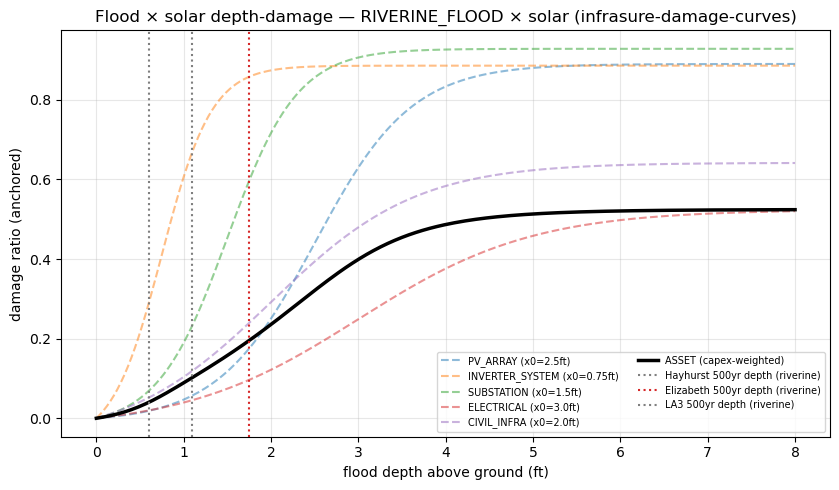

In [3]:
def asset_dr(depth_ft):
    return float(sum(r.capex_weight * dr_anchored(depth_ft, r.L, r.k, r.x0_ft) for r in curves.itertuples()))


import matplotlib.pyplot as plt

xs = np.linspace(0, 8, 200)
fig, ax = plt.subplots(figsize=(8.5, 5))
for r in curves.itertuples():
    ax.plot(xs, [dr_anchored(x, r.L, r.k, r.x0_ft) for x in xs], "--", alpha=0.5,
            label=f"{r.subsystem} (x0={r.x0_ft}ft)")
ax.plot(xs, [asset_dr(x) for x in xs], "k-", lw=2.5, label="ASSET (capex-weighted)")
for _, s in m2[(m2.rp_years == 500) & (m2.sub_peril == "riverine")].iterrows():
    ax.axvline(s["conditional_depth_m"] / FT_M, color="C3" if "Eliz" in s["name"] else "C7", ls=":",
               label=f"{s['name'].split()[0]} 500yr depth (riverine)")
ax.set_xlabel("flood depth above ground (ft)"); ax.set_ylabel("damage ratio (anchored)")
ax.set_title("Flood × solar depth-damage — RIVERINE_FLOOD × solar (infrasure-damage-curves)")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3 · Conditional loss per site × return period

`conditional_loss = exposure_fraction × Asset_DR(conditional_depth) × TIV`. TIV from $/MW (Hayhurst's hail TIV
basis, $1.483 M/MW, reused for cross-peril coherence; Elizabeth estimated by capacity).

In [4]:
TIV_PER_MW = 36_778_400 / 24.8     # Hayhurst hail TIV basis
# MW from BOTH solar rosters (inland: Hayhurst/Elizabeth/LA3 · coastal: Discovery/LA3) so the all-three LA3 + the
# coastal-only Discovery both resolve — no hardcoded dict (JD-FL-17 unify).
MW = ({s["name"]: s["solar_mw"] for s in json.loads((OUT / "flood_solar_m0_sites.json").read_text())["sites"]}
      | {s["name"]: s["solar_mw"] for s in json.loads((OUT / "flood_solar_coastal_m0_sites.json").read_text())["sites"]})
m2["tiv_usd"] = m2["name"].map(lambda n: round(MW[n] * TIV_PER_MW))
m2["depth_ft"] = m2["conditional_depth_m"] / FT_M
m2["asset_dr"] = m2["depth_ft"].map(asset_dr).round(4)
m2["cond_loss_frac_tiv"] = (m2["exposure_fraction"] * m2["asset_dr"]).round(4)
m2["cond_loss_usd"] = (m2["cond_loss_frac_tiv"] * m2["tiv_usd"]).round(0)
print(m2[["sub_peril", "name", "rp_years", "depth_ft", "exposure_fraction", "asset_dr", "cond_loss_frac_tiv", "cond_loss_usd"]]
      .to_string(index=False))

sub_peril                                name  rp_years  depth_ft  exposure_fraction  asset_dr  cond_loss_frac_tiv  cond_loss_usd
 riverine                Hayhurst Texas Solar       100  0.521654              0.087    0.0321              0.0028       102980.0
 riverine                Hayhurst Texas Solar       500  0.600394              0.150    0.0400              0.0060       220670.0
 riverine               Elizabeth Solar Plant       100  1.420604              0.177    0.1464              0.0259      5484905.0
 riverine               Elizabeth Solar Plant       500  1.745407              0.218    0.1946              0.0424      8979150.0
 riverine LA3 West Baton Rouge Solar Facility       100  1.164698              0.509    0.1110              0.0565      4189475.0
 riverine LA3 West Baton Rouge Solar Facility       500  1.099081              0.953    0.1022              0.0974      7222210.0
 riverine               Elizabeth Solar Plant        10  1.007218              0.102    0.

## 3b · Coastal — per-storm surge damage (same curve), for each coastal-exposed solar site

Apply the **same** flood × solar curve to the coastal M2 per-storm conditional depth → per-storm surge loss, for
Discovery + the all-three **LA3**. Output: per-site `*_flood_solar_coastal_m3_surge_loss.parquet` (event-based,
`event_family_id`-stamped) — the input M4's coastal compound combine joins to the hurricane wind leg (JD-FL-12).

In [5]:
cman = json.loads((OUT / "flood_coastal_m1_catalog_manifest.json").read_text())
coastal_solar = [c for c in cman["sites"] if c["asset"] == "solar" and c["exposed"]]
coa_summ = []
for cs in coastal_solar:
    cslug, nm = cs["slug"], cs["name"]; TIV = MW[nm] * TIV_PER_MW
    cc = pd.read_parquet(OUT / f"{cslug}_flood_solar_coastal_m2_coupling.parquet")
    cc["asset_dr"] = cc["conditional_depth_ft"].map(asset_dr).round(5)
    cc["surge_loss_frac_tiv"] = (cc["exposure_fraction"] * cc["asset_dr"]).round(5)
    cc["surge_loss_usd"] = (cc["surge_loss_frac_tiv"] * TIV).round(0); cc["tiv_usd"] = round(TIV)
    keep = ["site", "slug", "storm_ID", "event_family_id", "category", "near_site_vmax_kt", "min_dist_km",
            "surge_depth_ft", "conditional_depth_ft", "exposure_fraction", "asset_dr",
            "surge_loss_frac_tiv", "surge_loss_usd", "tiv_usd", "depth_source"]
    cc[keep].sort_values("event_family_id").to_parquet(OUT / f"{cslug}_flood_solar_coastal_m3_surge_loss.parquet", index=False)
    coa_summ.append({"name": nm, "slug": cslug, "n_storms": int(len(cc)), "tiv_usd": round(TIV),
                     "max_event_surge_loss_pct": round(float(cc["surge_loss_frac_tiv"].max()) * 100, 3)})
    print(f"  coastal {nm:24s}: {len(cc)} storms · max event surge loss {cc['surge_loss_frac_tiv'].max()*100:.2f}% of TIV "
          f"(${cc['surge_loss_usd'].max()/1e6:.1f}M)")

  coastal Discovery Solar Center  : 117 storms · max event surge loss 52.39% of TIV ($57.9M)
  coastal LA3 West Baton Rouge Solar Facility: 11 storms · max event surge loss 52.39% of TIV ($38.8M)


## 4 · Known-answer checks (basics-spot-on)

- **Anchored:** `Asset_DR(0) = 0`. **Inversion:** the inverter (x0 0.75 ft) dominates at shallow depth.
- **Monotone:** damage + conditional loss rise 100-yr → 500-yr. **Contrast:** Elizabeth ≫ Hayhurst.

In [6]:
assert abs(asset_dr(0.0)) < 1e-9, "Asset_DR(0) must be 0 (anchored)"
assert dr_anchored(1.0, 0.95, 3.5, 0.75) > dr_anchored(1.0, 0.9, 1.8, 2.5), "inverter should drown before panels (inversion)"
riv = m2[m2.sub_peril == "riverine"]
eliz = riv[riv.name == "Elizabeth Solar Plant"].set_index("rp_years")
hay = riv[riv.name == "Hayhurst Texas Solar"].set_index("rp_years")
assert eliz.loc[500, "cond_loss_frac_tiv"] >= eliz.loc[100, "cond_loss_frac_tiv"] > 0, "Elizabeth riverine loss should grow 100→500yr"
assert eliz.loc[500, "cond_loss_frac_tiv"] > 3 * hay.loc[500, "cond_loss_frac_tiv"], "Elizabeth riverine should dominate Hayhurst"
# pluvial priced too, monotone, both sites
pluv = m2[(m2.sub_peril == "pluvial") & (m2.name == "Elizabeth Solar Plant")].sort_values("rp_years")
assert pluv["cond_loss_frac_tiv"].is_monotonic_increasing and pluv["cond_loss_frac_tiv"].iloc[-1] > 0, "pluvial loss should grow with RP"
print(f"✓ anchored: Asset_DR(0)=0 | inverter drowns before panels (DR@1ft: inv {dr_anchored(1,0.95,3.5,0.75):.2f} > pv {dr_anchored(1,0.9,1.8,2.5):.2f})")
print(f"✓ riverine Elizabeth: 100yr {eliz.loc[100,'cond_loss_frac_tiv']*100:.2f}% → 500yr {eliz.loc[500,'cond_loss_frac_tiv']*100:.2f}% TIV (grows, dominates Hayhurst)")
print(f"✓ pluvial Elizabeth: 10yr {pluv['cond_loss_frac_tiv'].iloc[0]*100:.2f}% → 500yr {pluv['cond_loss_frac_tiv'].iloc[-1]*100:.2f}% TIV (priced, grows)")
print("✓ M3 known-answer checks pass (riverine + pluvial).")

✓ anchored: Asset_DR(0)=0 | inverter drowns before panels (DR@1ft: inv 0.61 > pv 0.05)
✓ riverine Elizabeth: 100yr 2.59% → 500yr 4.24% TIV (grows, dominates Hayhurst)
✓ pluvial Elizabeth: 10yr 0.03% → 500yr 0.03% TIV (priced, grows)
✓ M3 known-answer checks pass (riverine + pluvial).


## 5 · Vendor the curve + persist the M3 manifest

In [7]:
(OUT / "damage_curves").mkdir(parents=True, exist_ok=True)
vendored = {
    "curve_id": "flood/solar__asset__capex_weighted", "hazard_type": "RIVERINE_FLOOD", "asset_type": "solar",
    "intensity_metric": "flood_depth_ft", "intensity_unit": "ft",
    "logistic_form": "DR(x) = L / (1 + exp(-k*(x - x0)))", "anchoring": "minus DR(0) so DR(0)=0",
    "aggregation": "Asset_DR = Σ wᵢ·DRᵢ_anchored; uncovered→0; loss = exposure × Asset_DR(conditional_depth) × TIV",
    "subsystems": json.loads(curves.to_json(orient="records")),
    "uncovered_subsystems_zero_damage": {**UNCOVERED, "note": "no flood curve → flood-immune"},
    "metadata": {
        "source_repo": "infrasure-damage-curves (Divi-patel/infrasure-damage-curves)",
        "component_curves": "infrasure-damage-curves (RIVERINE_FLOOD × solar) (RIVERINE_FLOOD × solar, priority 4)",
        "capex_weights": "NREL solar BoS (vendored from hail_solar_asset_capex_weighted.json) — peril-independent",
        "confidence": "medium; x0 encodes component elevation (the flood inversion); duration unmodeled (Gen-1)",
        "pv_variant": "single-axis horizontal stow (x0 2.5 ft); flood-stow (x0 7 ft) = mitigation lever",
    },
}
(OUT / "damage_curves" / "flood_solar_asset_capex_weighted.json").write_text(json.dumps(vendored, indent=2))

manifest = {
    "peril": "flood", "sub_peril": ["riverine", "pluvial", "coastal"], "event_family_id": None, "layer": "M3",
    "curve": "infrasure-damage-curves RIVERINE_FLOOD × solar, capex-weighted, anchored (medium confidence) — source-agnostic, all three sub-perils",
    "conditional_loss_rule": "exposure × Asset_DR(conditional_depth) × TIV",
    "tiv_basis": f"${TIV_PER_MW:,.0f}/MW (Hayhurst hail TIV); Elizabeth/LA3 estimated",
    "rp_sites": json.loads(m2.to_json(orient="records")),                          # riverine + pluvial (RP-indexed)
    "coastal_sites": coa_summ,                                                     # per-storm surge_loss parquets keyed by slug
    "sites": json.loads(m2.to_json(orient="records")),                            # back-compat alias (= rp_sites)
}
(OUT / "flood_solar_m3_damage_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "damage_curves" / "flood_solar_asset_capex_weighted.json")
print("wrote:", OUT / "flood_solar_m3_damage_manifest.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/damage_curves/flood_solar_asset_capex_weighted.json
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_m3_damage_manifest.json


## Findings & what's next

- **Canonical depth-damage applied:** the `infrasure-damage-curves` RIVERINE_FLOOD × solar set, capex-weighted —
  same library + recipe as hail/wildfire/wind. The **flood inversion** shows: the inverter (x0 0.75 ft) dominates
  shallow-flood damage; elevated panels and underground cables resist.
- **Conditional loss per site × RP** computed as exposure × Asset_DR × TIV (% of TIV + dollars). Elizabeth grows
  100-yr → 500-yr and dominates the Hayhurst baseline.
- **Honest limits:** medium-confidence curves; duration unmodeled (Gen-1); `value ∝ area` exposure; Elizabeth TIV
  estimated. **Mitigation lever noted:** PV flood-stow (x0 7 ft) for a later resiliency pass.
- **Next — M4 (loss & metrics):** feed the conditional losses through the shared MC — inland (riverine + pluvial)
  **annual-maximum**, co-sampled worse-source-wins (JD-FL-11); coastal **compound-Poisson** surge×wind (JD-FL-12);
  total = inland + coastal → EAL / VaR / PML / TVaR (% of TIV). The event-model bridge is settled (JD-FL-7); the
  inland RP curve is now 5-point (densified, JD-FL-8).